In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');

### Objective
Figure out what objective makes segmentation optimal.

In [2]:
def create_event_templates(n_events, n_dims, between_event_drift, rng):
    event_templates = []
    while len(event_templates) < n_events:  event_templates.append(rng.normal(len(event_templates)*between_event_drift, 0, n_dims))
    return np.array(event_templates)

def fill_event_with_scenes(event_template, event_length, within_event_drift, rng):
    scenes = np.zeros((event_length, event_template.size))
    scenes[0] = event_template
    for t in range(1, event_length): scenes[t] = scenes[t-1] + rng.normal(0, within_event_drift, event_template.size)
    return scenes

def make_stimulus(n_events=6, n_dims=8, avg_event_len=10, sd_event_len=2, between_event_drift=10, within_event_drift=.5, seed=0):
    rng = np.random.default_rng(seed)

    true_event_ids = np.arange(n_events)
    true_event_templates = create_event_templates(n_events, n_dims, between_event_drift,rng)
    true_event_lengths   = rng.integers(avg_event_len - sd_event_len, avg_event_len + sd_event_len + 1, n_events)
    true_event_bounds = np.cumsum(true_event_lengths)[:-1]
    true_stream_list = [fill_event_with_scenes(true_event_templates[e], true_event_lengths[e], within_event_drift, rng) for e in range(n_events)]
    true_stream = np.vstack(true_stream_list)  # (T, n_dims)

    stim_event_ids = rng.permutation(n_events)
    stim_event_templates = true_event_templates[stim_event_ids]
    stim_event_lengths = true_event_lengths[stim_event_ids]
    stim_event_bounds = np.cumsum(stim_event_lengths)[:-1] if stim_event_lengths.size > 0 else np.array([])
    stim_stream = np.vstack([true_stream_list[e] for e in stim_event_ids])

    return true_event_ids, true_event_templates, true_event_lengths, true_event_bounds, true_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream

def sort(true_stream, stim_stream, chunk_size):
    sorted_stream = [np.mean(stim_stream[:chunk_size], axis=0)]*chunk_size  # initialize
    insertion_count = 0
    for scene_t in range(chunk_size, len(stim_stream), chunk_size):
        stim_stream_chunk = stim_stream[scene_t:scene_t+chunk_size]
        for sorted_stream_idx in range(0, len(sorted_stream), chunk_size):
            sorted_stream_chunk = sorted_stream[sorted_stream_idx:sorted_stream_idx+chunk_size]
            if np.mean(stim_stream_chunk, axis=0) < np.mean(sorted_stream_chunk, axis=0):
                sorted_stream[sorted_stream_idx:sorted_stream_idx] = [np.mean(stim_stream_chunk, axis=0)]*len(stim_stream_chunk)
                insertion_count += 1; break
        else: sorted_stream.extend([np.mean(stim_stream_chunk, axis=0)]*len(stim_stream_chunk))
    return sorted_stream, insertion_count

def get_optimal_chunk_size(true_stream, stim_stream, avg_event_len):
    chunk_sizes, insertion_counts, recon_errs = list(range(1, 2*avg_event_len)), [], []
    for chunk_size in chunk_sizes:
        sorted_stream, insertion_count = sort(true_stream, stim_stream, chunk_size=chunk_size)
        recon_err = np.mean((np.array(sorted_stream)-true_stream)**2)
        insertion_counts.append(insertion_count); recon_errs.append(recon_err)
    optimal_chunk_size = chunk_sizes[np.argmin(norm01(np.array(insertion_counts)) + norm01(np.array(recon_errs)))]
    return optimal_chunk_size


Trial

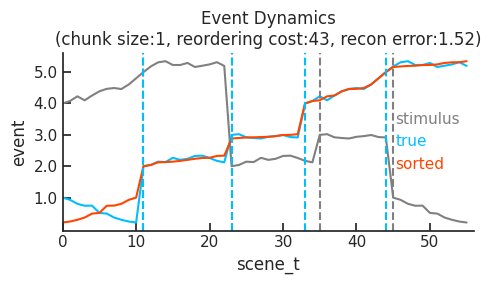

In [3]:
seed, n_events, n_dims, avg_event_len, sd_event_len = 0, 5, 1, 10, 2
between_event_drift, within_event_drift  = 5, .5
chunk_size = 1 # 1 or avg_event_len

true_event_ids, true_event_templates, true_event_lengths, true_event_bounds, true_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream =\
    make_stimulus(seed=seed, n_events=n_events, avg_event_len=avg_event_len, sd_event_len=sd_event_len, between_event_drift=between_event_drift, within_event_drift=within_event_drift, n_dims=n_dims)
sorted_stream, insertion_count =\
    sort(true_stream, stim_stream, chunk_size=chunk_size)
recon_err = np.mean((np.array(sorted_stream)-true_stream)**2)

plt.figure(figsize=(5,3)); plt.title(f"Event Dynamics\n(chunk size:{chunk_size}, reordering cost:{insertion_count}, recon error:{recon_err:.2f})")
for stim_dim in range(stim_stream.shape[1]): plt.plot(stim_stream[:, stim_dim], c='gray',label='stimulus')
for stim_dim in range(true_stream.shape[1]): plt.plot(true_stream[:, stim_dim],   c='deepskyblue', label='true')
for stim_dim in range(true_stream.shape[1]): plt.plot(np.array(sorted_stream)[:, stim_dim],   c='orangered', label='sorted')
for bound in stim_event_bounds: plt.axvline(bound, ls="--", c='gray')
for bound in true_event_bounds: plt.axvline(bound, ls="--", c='deepskyblue')
plt.xlabel("scene_t"); plt.ylabel("event"); plt.xlim(0,len(sorted_stream))
plt.yticks(np.linspace(0,between_event_drift*(n_events-1),between_event_drift), np.linspace(1,n_events,between_event_drift))
leg = plt.legend(frameon=False, handlelength=0, handletextpad=0)
for t in leg.get_texts(): t.set_color({'stimulus':'gray','true':'deepskyblue','sorted':'orangered'}[t.get_text()])
plt.tight_layout(); plt.show()


Loop

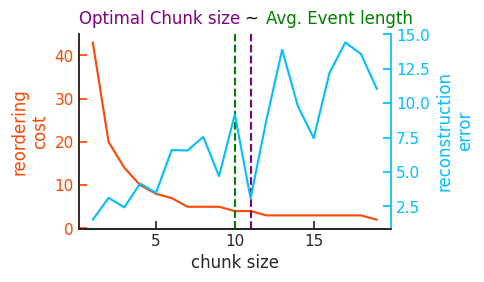

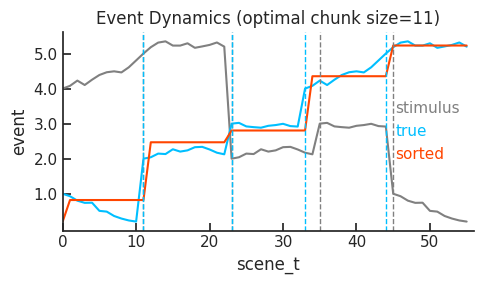

In [4]:
# generate stim
true_event_ids, true_event_templates, true_event_lengths, true_event_bounds, true_stream, stim_event_ids, stim_event_templates, stim_event_lengths, stim_event_bounds, stim_stream =\
    make_stimulus(seed=seed, n_events=n_events, avg_event_len=avg_event_len, sd_event_len=sd_event_len, between_event_drift=between_event_drift, within_event_drift=within_event_drift, n_dims=n_dims)

# sweep chunk sizes
chunk_sizes, insertion_counts, recon_errs = list(range(1, 2*avg_event_len)), [], []
for chunk_size in chunk_sizes:
    sorted_stream, insertion_count = sort(true_stream, stim_stream, chunk_size=chunk_size)
    recon_err = np.mean((np.array(sorted_stream)-true_stream)**2)
    insertion_counts.append(insertion_count); recon_errs.append(recon_err)
optimal_chunk_size = chunk_sizes[np.argmin(norm01(np.array(insertion_counts)) + norm01(np.array(recon_errs)))]

# plot sweep
fig, ax1 = plt.subplots(figsize=(5,3)); ax2 = ax1.twinx()
ax1.set(xlabel="chunk size", ylabel="reordering\ncost")
ax1.text(0,1.05,"Optimal Chunk size",transform=ax1.transAxes,color='purple')
ax1.text(.53,1.05,"~",transform=ax1.transAxes,color='black')
ax1.text(.6,1.05,"Avg. Event length",transform=ax1.transAxes,color='green')
ax2.set(ylabel="reconstruction\nerror")
ax1.plot(chunk_sizes,insertion_counts,c='orangered')
ax2.plot(chunk_sizes,recon_errs,c='deepskyblue')
ax1.axvline(optimal_chunk_size, ls="--", c='purple'); ax1.axvline(avg_event_len, ls="--", c='green')
ax1.spines['left'].set_color('orangered'); ax1.tick_params(axis='y', colors='orangered'); ax1.yaxis.label.set_color('orangered')
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color('deepskyblue'); ax2.tick_params(axis='y', colors='deepskyblue'); ax2.yaxis.label.set_color('deepskyblue')
plt.tight_layout(); plt.show()

# plot optimal chunk size result
sorted_stream, insertion_count = sort(true_stream, stim_stream, chunk_size=optimal_chunk_size)
recon_err = np.mean((np.array(sorted_stream)-true_stream)**2)
plt.figure(figsize=(5,3)); plt.title(f"Event Dynamics (optimal chunk size={optimal_chunk_size})")
for stim_dim in range(stim_stream.shape[1]): plt.plot(stim_stream[:, stim_dim], c='gray',label='stimulus')
for stim_dim in range(true_stream.shape[1]):   plt.plot(true_stream[:, stim_dim],   c='deepskyblue', label='true')
for stim_dim in range(true_stream.shape[1]):   plt.plot(np.array(sorted_stream)[:, stim_dim],   c='orangered', label='sorted')
for bound in stim_event_bounds: plt.axvline(bound, ls="--", lw=1, c='gray')
for bound in true_event_bounds: plt.axvline(bound, ls="--", lw=1, c='deepskyblue')
plt.xlabel("scene_t"); plt.ylabel("event"); plt.xlim(0,len(sorted_stream))
plt.yticks(np.linspace(0,between_event_drift*(n_events-1),between_event_drift), np.linspace(1,n_events,between_event_drift))

leg = plt.legend(frameon=False, handlelength=0, handletextpad=0)
for t in leg.get_texts(): t.set_color({'stimulus':'gray','true':'deepskyblue','sorted':'orangered'}[t.get_text()])
plt.tight_layout(); plt.show()


In [5]:
# n_events, avg_event_len
for n_events in [5, 6, 7]:
    for avg_event_len in [10, 12, 14]:
        

SyntaxError: incomplete input (2143189092.py, line 4)